In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

# Resolve the project root (the folder holding oiltrace_paths.py) by walking up
# from this notebook's working directory, then import the shared path definitions.
# No path below depends on where the project was cloned.
ROOT = Path.cwd().resolve()
while not (ROOT / "oiltrace_paths.py").is_file():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("Run this notebook from inside the OilTrace project")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

import oiltrace_paths as paths

# The model architecture and inference wrapper now live in model.py, which sits
# next to this notebook. Import them instead of redefining inline.
sys.path.insert(0, str(Path.cwd()))
from model import UNet, load_model, predict_oil_spill

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Project root:", paths.ROOT)


Using device: cuda
Project root: F:\Events\SIH 2026\OilTrace - Development


In [2]:
class SARDataset(Dataset):
    def __init__(self, img_dir, label_dir):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.files = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert("L")
        label = Image.open(os.path.join(self.label_dir, fname)).convert("L")

        img = np.array(img, dtype=np.float32) / 255.0
        label = np.array(label, dtype=np.float32) / 255.0

        img_tensor = torch.from_numpy(img).unsqueeze(0)
        label_tensor = torch.from_numpy(label).unsqueeze(0)

        return img_tensor, label_tensor

In [3]:
# Dataset root is project-relative (see oiltrace_paths.py). The dataset is not
# committed to git - set OILTRACE_DATASET if your copy lives outside the project.
sentinel_test_img = paths.SENTINEL_TEST_IMG
sentinel_test_label = paths.SENTINEL_TEST_LABEL

test_dataset = SARDataset(sentinel_test_img, sentinel_test_label)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Dataset root:", paths.DATASET_DIR)
print("Test samples:", len(test_dataset))

Dataset root: F:\Events\SIH 2026\OilTrace - Development\dataset
Test samples: 839


In [4]:
# DoubleConv and UNet are defined in model.py (imported in the first cell) -
# the same classes the backend loads via detection.model.


### Loading trained model straight for inference

In [5]:
model = load_model(paths.MODEL_BEST, device)
print("Loaded trained model - ready for inference")
print("Weights:", paths.MODEL_BEST)


Loaded trained model - ready for inference
Weights: F:\Events\SIH 2026\OilTrace - Development\ml\detection\checkpoints\sar_unet_best.pt


In [6]:
def compute_iou(pred, target, threshold = 0.5, eps = 1e-7):
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum() - intersection
    return((intersection + eps) / (union + eps)).item()

iou_scores = []
with torch.no_grad():
    for imgs, labels in test_loader: 
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs)
        for i in range(preds.shape[0]):
            iou_scores.append(compute_iou(preds[i], labels[i]))

avg_iou = sum(iou_scores) / len(iou_scores)
print(f"Average IoU: {avg_iou:.4f} on {len(iou_scores)} test images")

Average IoU: 0.6630 on 839 test images


## Model Summary: 

In [7]:
import json

results_summary = {
    "model": "U-Net (Sentinel-1 SAR segmentation)",
    "dataset": "Deep-SAR SOS Oil Spill Segmentation (Kaggle, Sentinel-1 subset)",
    "total_epochs_trained": 100,
    "average_test_iou": avg_iou,
    "num_test_images": len(iou_scores),
    "trained_on": "First 10 epochs on local RTX 5060 laptop GPU, remaining 90 epochs on a rented RTX 5090",
    "known_limitations": "Some false positives observed on look-alike/no-spill test cases (a documented challenge in SAR oil-spill detection research)",
}

with open(paths.RESULTS_JSON, "w") as f:
    json.dump(results_summary, f, indent=2)

print(json.dumps(results_summary, indent=2))

{
  "model": "U-Net (Sentinel-1 SAR segmentation)",
  "dataset": "Deep-SAR SOS Oil Spill Segmentation (Kaggle, Sentinel-1 subset)",
  "total_epochs_trained": 100,
  "average_test_iou": 0.6630316632314667,
  "num_test_images": 839,
  "trained_on": "First 10 epochs on local RTX 5060 laptop GPU, remaining 90 epochs on a rented RTX 5090",
  "known_limitations": "Some false positives observed on look-alike/no-spill test cases (a documented challenge in SAR oil-spill detection research)"
}


## Visualization 

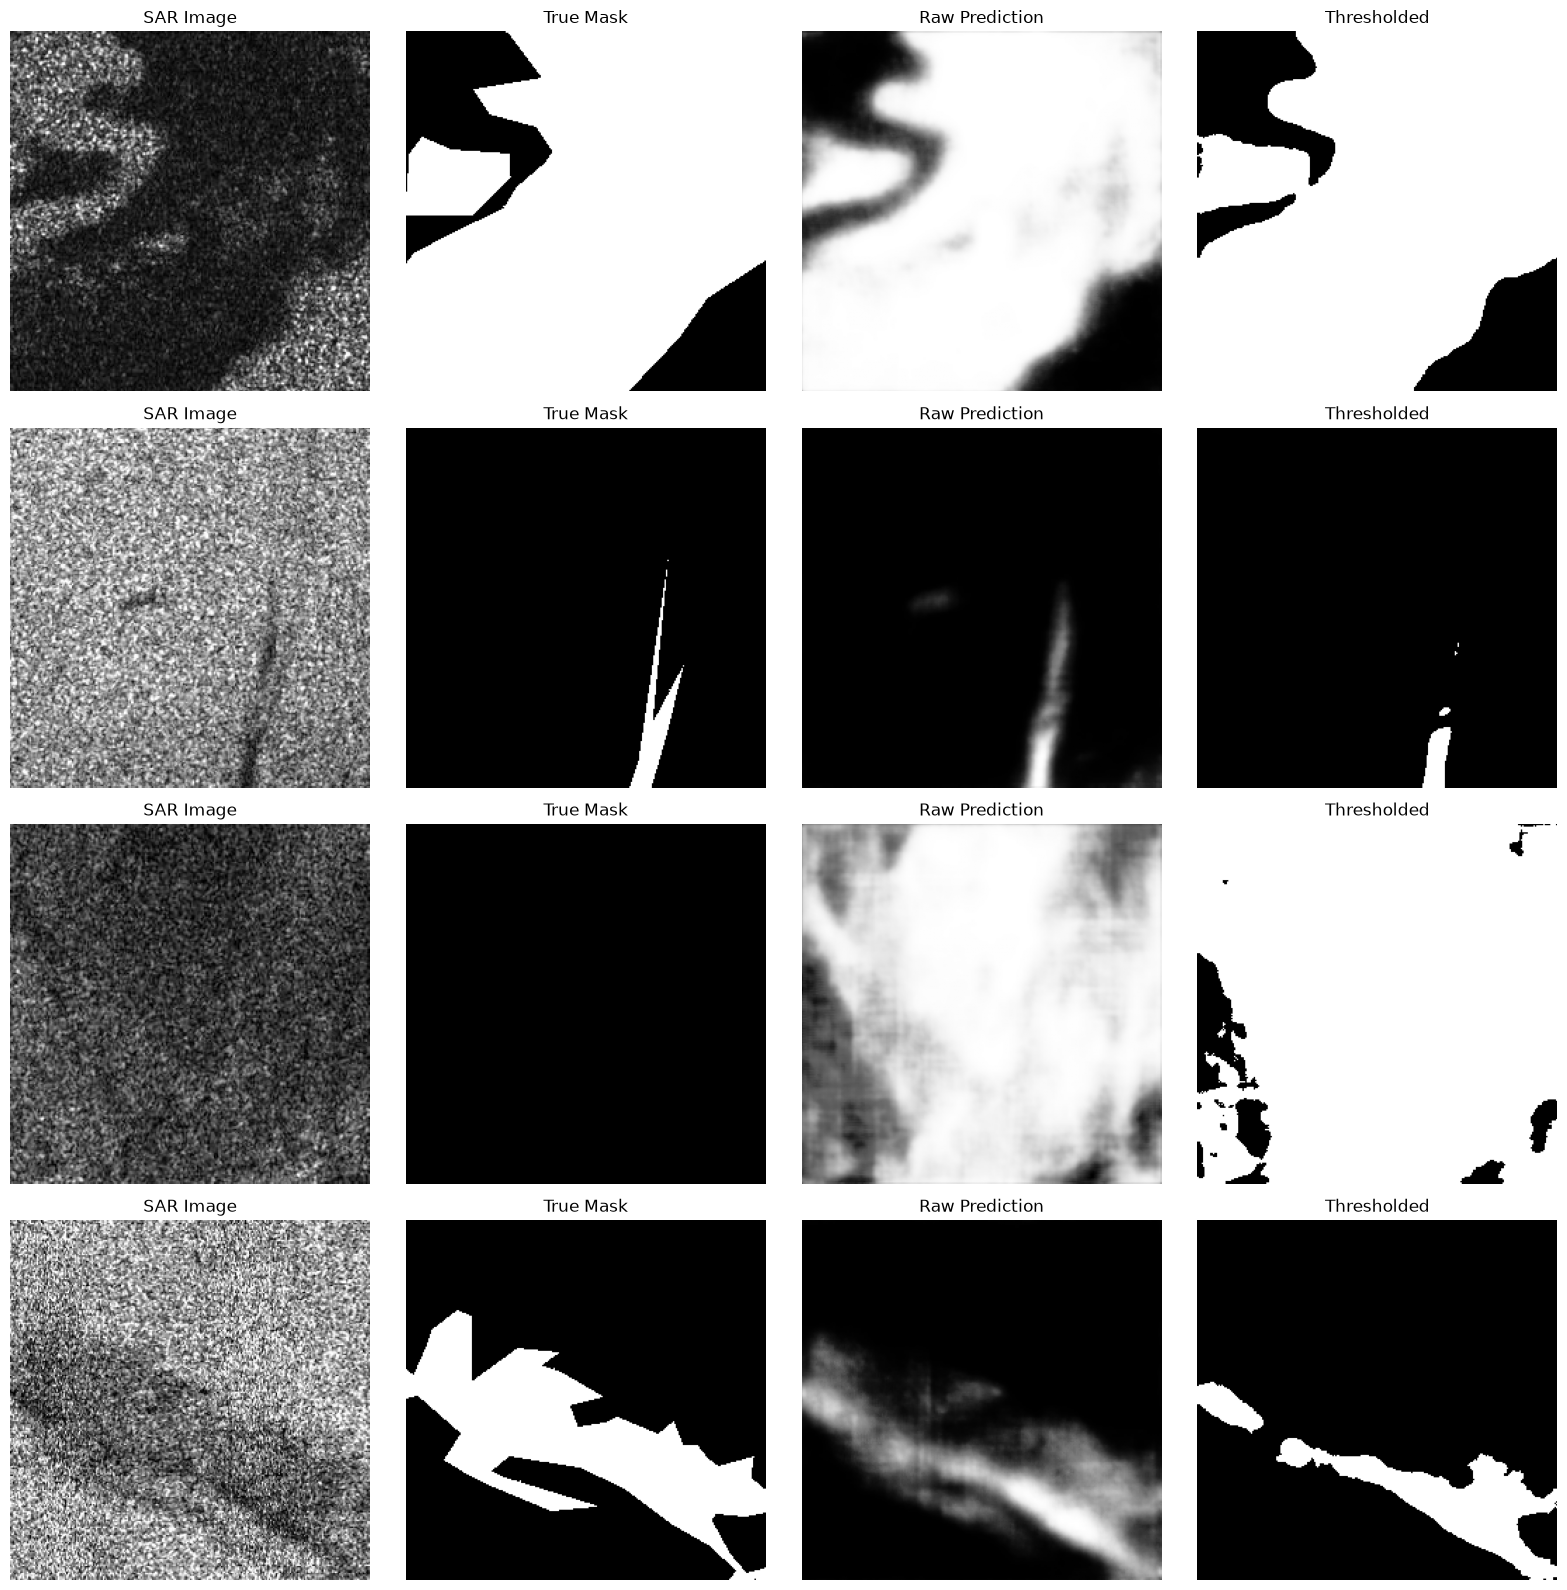

In [8]:
test_imgs, test_labels = next(iter(test_loader))
test_imgs, test_labels = test_imgs.to(device), test_labels.to(device)

with torch.no_grad():
    predictions = model(test_imgs)

binary_preds = (predictions > 0.5).float()

num_examples = 4
fig, axes = plt.subplots(num_examples, 4, figsize = (16, 4 * num_examples))

for i in range(num_examples):
    axes[i, 0].imshow(test_imgs[i, 0].cpu(), cmap='gray'); axes[i, 0].set_title("SAR Image"); axes[i, 0].axis('off')
    axes[i, 1].imshow(test_labels[i, 0].cpu(), cmap='gray'); axes[i, 1].set_title("True Mask"); axes[i, 1].axis('off')
    axes[i, 2].imshow(predictions[i, 0].cpu(), cmap='gray'); axes[i, 2].set_title("Raw Prediction"); axes[i, 2].axis('off')
    axes[i, 3].imshow(binary_preds[i, 0].cpu(), cmap='gray'); axes[i, 3].set_title("Thresholded"); axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

Oil is White (1), Water is Black (0)
Row 3 Raw Prediction is false-positive

### Inference wrapper function - for backend

In [9]:
# predict_oil_spill() is defined in model.py (imported in the first cell) -
# the same function the backend calls through detection.model.


### Wrapper test:

Oil area fraction: 80.43%


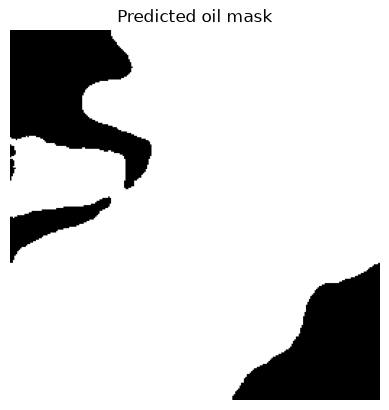

In [10]:
img_files = sorted(p for p in sentinel_test_img.iterdir() if p.is_file())
sample_path = img_files[0]

result = predict_oil_spill(sample_path, model, device)
print("Oil area fraction:",f"{result['oil_area_fraction']:.2%}")

plt.imshow(result['mask'], cmap='gray')
plt.title("Predicted oil mask")
plt.axis('off')
plt.show()